In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np

In [60]:
named = {
    "rtasipp": "RTAS",
    "plrtosipp": "MaxATFS",
    "hybrid": "MedATFS",
    "plrtosipphonly": "PLRTS"
}

colord = {
    "plrtosipphonly": "k",
    "rtasipp": "b",
    "hybrid": "r",
    "plrtosipp": "g"
    
    
}
plt.rcParams.update({'font.size': 16})

In [82]:
def plot_figure(folder, pattern, name, upper, num):
    dat = []
    for file_name in glob(folder + pattern):
        fn = file_name.replace(folder,"")
        try:
            #print(fn.replace(".out", "").split("_"))
            map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
        except:
            continue
        lookahead = int(lookahead)
        cost = float("inf")
        expansions = float("inf")
        with open(file_name) as f:
            for line in f.readlines():
                if "Arrival time:" in line:
                    cost = float(line.split(": ")[1])
                if "Nodes expanded:" in line:
                    expansions = int(line.split("Nodes expanded: ")[1].split()[0])
        dat.append((map, alg, lookahead, rep, expansions, cost))
    data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead","rep", "expansions", "cost"])
    plt.figure(figsize = (8, 4))
    for alg in colord:
        d = data.loc[data.Algorithm == alg]
        d = d.sort_values("Lookahead")
        x = []
        y = []
        yerr = []
        for lookahead in set(d.Lookahead):
            if (lookahead < 4) or (lookahead > upper):
               continue
            #if (d.loc[d.Lookahead== lookahead].cost < 10000).all():
            
            dat = d.loc[d.Lookahead == lookahead].cost
            
            # for i in range(num - len(dat)):
            #     dat = pd.concat((dat, pd.Series([10000, float('inf')])))
            dat = dat.sort_values()
            n = len(dat)
            q = 0.5
            z = 1.96
            if n < num:
                continue
            x.append(lookahead)
            y.append(d.loc[(d.Lookahead == lookahead)].cost.mean())
            j = int(np.ceil(n*q - z*np.sqrt(n*q*(1-q))))
            k = int(np.ceil(n*q + z*np.sqrt(n*q*(1-q))))
            #print(n, j, k)
            yerr.append((dat.median(), dat.iloc[j], dat.iloc[k]))
        x = np.asarray(x)
        y = np.asarray(y)
        yerr = np.asarray(yerr).T
        ind = np.argsort(x)
        x = x[ind]
        y = y[ind]
        yerr = yerr[:,ind]
        plt.plot(x, yerr[0], color = colord[alg])
        plt.fill_between(x, yerr[1] , yerr[0], label = named[alg], alpha = .35 , color = colord[alg])
        plt.fill_between(x, yerr[0] , yerr[2], alpha = .25 , color = colord[alg])
    #plt.ylim((100, 10000))
    plt.legend()
    plt.loglog()
    plt.ylabel("Goal Achievment Time")
    plt.xlabel("Search Budget (Expansions)")
    plt.tight_layout()
    plt.savefig(name)


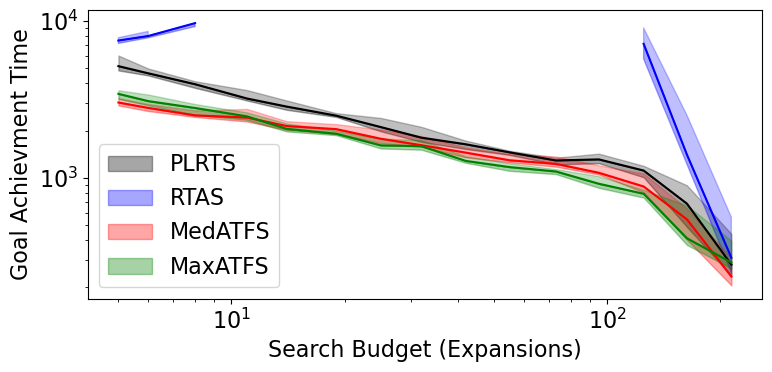

In [83]:
plot_figure("../results_overnight/", "*cup*", "cup_prelim.png", 256, 32)

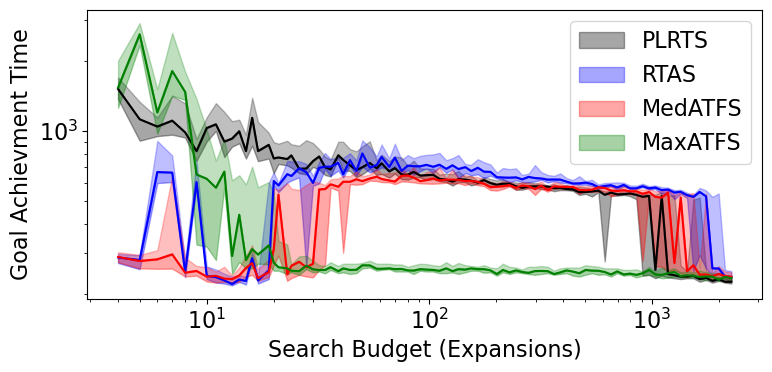

In [84]:
plot_figure("../results_overnight2/", "*warehouse*", "warehouse_prelim.png", 2400, 32)

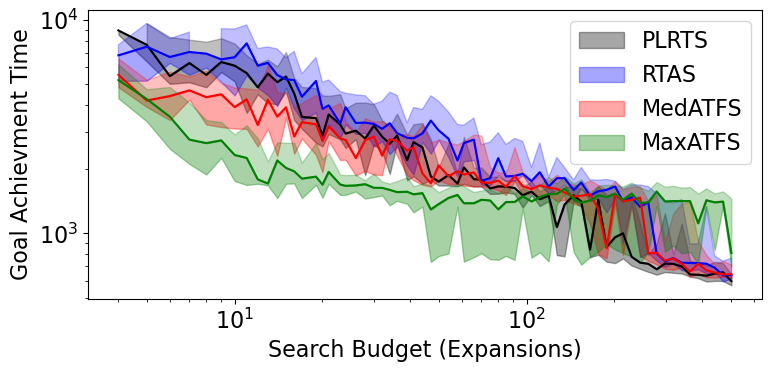

In [85]:
plot_figure("../results_overnight2/", "*den520d*", "den520d_prelim.png", 512, 32)

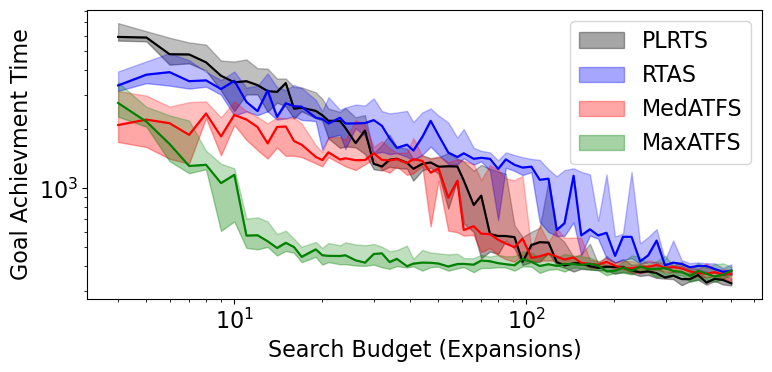

In [86]:
plot_figure("../results_sat2/", "*random*", "random_prelim.png", 512, 32)